In [1]:
import pandas as pd
import numpy as np
from minisom import MiniSom
from itertools import product

from som import (
    train_som_with_qe,
    plot_quant_errors,
    plot_u_matrix,
    plot_feature_maps,
    plot_hits_map,
    evaluate_som,
    read_newdata
    
)

In [2]:
info_clustering = read_newdata()

In [3]:
info_clustering.set_index('customer_id', inplace=True)

In [4]:
info_clustering

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,latitude,longitude,age,hour_sin,hour_cos,years_education,years_since_first_transaction,lifetime_spend_techonology,has_loyalty_card,customer_gender
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,1.0,1.0,0.0,0.5,-0.375254,0.323394,1.214118,0.567444,1.029630,1.222782,...,-0.758309,0.895939,-0.027101,-0.183013,-0.366025,-0.6,-0.428571,0.632947,0,1
6813,-1.0,0.0,-1.0,0.5,-0.332876,0.399083,-0.809412,-0.622151,-0.240000,-0.337702,...,-0.382712,-0.187761,0.855364,-0.353553,-0.224745,0.0,0.285714,-0.656762,1,0
39451,1.0,1.0,-1.0,1.5,0.008118,1.308486,1.256471,1.274336,0.622222,1.300403,...,1.149384,0.281558,-0.600101,-0.353553,-0.224745,-0.6,0.571429,0.326415,0,1
16415,0.0,0.0,0.0,1.0,1.658394,-0.213303,0.658824,-0.146956,0.118519,0.817540,...,1.114183,0.220402,0.150113,-0.353553,-0.224745,1.4,0.428571,0.042167,1,0
22853,0.0,0.0,0.0,0.0,0.551196,1.857798,-0.157647,-0.131939,-1.334815,-0.638105,...,0.905467,-0.533152,0.674102,-0.707107,1.000000,1.4,0.285714,0.103343,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37071,0.0,0.0,-1.0,-0.5,2.299522,0.423165,0.192941,0.901046,-0.320000,1.014113,...,0.088835,1.515551,-0.895312,-0.612372,0.292893,-0.6,-0.428571,0.549050,0,1
27422,0.0,0.0,-1.0,0.0,0.031613,0.066514,0.710588,0.010727,0.440000,-0.113911,...,-0.080351,-0.348471,-0.430278,-0.183013,-0.366025,-0.6,-0.571429,0.206030,1,0
39540,0.0,-1.0,0.0,-0.5,-0.039657,-0.048165,-0.432941,-0.214535,-0.583704,0.797379,...,0.585934,-0.439728,-0.948547,-0.683013,0.633975,-0.6,-0.428571,1.414027,0,1


In [5]:
cols_to_remove = ["customer_gender", "latitude", "longitude", "has_loyalty_card"]
info_clustering = info_clustering.drop(columns=cols_to_remove)

In [6]:
data_arr   = info_clustering.to_numpy(dtype=float)

In [7]:
results = pd.DataFrame(columns=[
    'grid_size', 'sigma', 'learning_rate',
    'neighborhood_function', 'qe', 'te'
])
param_grid = {
    'grid_size': [10, 15, 20, 25,30],
    'sigma': [0.3, 0.6, 1.0, 1.5],
    'learning_rate': [0.1, 0.5, 1.0],
    'neighborhood_function': ['gaussian', 'mexican_hat']
}

for (g, s, lr, nf) in product(param_grid['grid_size'],
                              param_grid['sigma'],
                              param_grid['learning_rate'],
                              param_grid['neighborhood_function']):

    qe, te = evaluate_som(
        data_arr               = data_arr,
        grid_size              = g,
        sigma                  = s,
        learning_rate          = lr,
        neighborhood_function  = nf,
        random_seed            = 42,
        n_iterations           = 2000
    )

    results.loc[len(results)] = {
        'grid_size': g,
        'sigma': s,
        'learning_rate': lr,
        'neighborhood_function': nf,
        'qe': round(qe, 4),
        'te': round(te, 4)
    }

results = results.sort_values(by=['qe', 'te']).reset_index(drop=True)
print(results.head(10))

/Users/davidcarrilho/anaconda3/envs/MachineLeaning2/lib/python3.11/site-packages/minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)
/Users/davidcarrilho/anaconda3/envs/MachineLeaning2/lib/python3.11/site-packages/minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)
/Users/davidcarrilho/anaconda3/envs/MachineLeaning2/lib/python3.11/site-packages/minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)
/Users/davidcarrilho/anaconda3/envs/MachineLeaning2/lib/python3.11/site-packages/minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


   grid_size  sigma  learning_rate neighborhood_function      qe      te
0         30    0.6            0.5              gaussian  1.6982  0.9896
1         30    0.3            0.5              gaussian  1.7093  0.9923
2         30    0.3            0.5           mexican_hat  1.7125  0.9915
3         30    1.5            1.0              gaussian  1.7302  0.4034
4         30    0.3            1.0              gaussian  1.7311  0.9919
5         30    0.3            1.0           mexican_hat  1.7328  0.9923
6         30    0.6            1.0              gaussian  1.7334  0.9887
7         30    1.0            0.1              gaussian  1.7389  0.9867
8         30    1.0            1.0              gaussian  1.7410  0.6923
9         25    0.6            0.5              gaussian  1.7421  0.9850


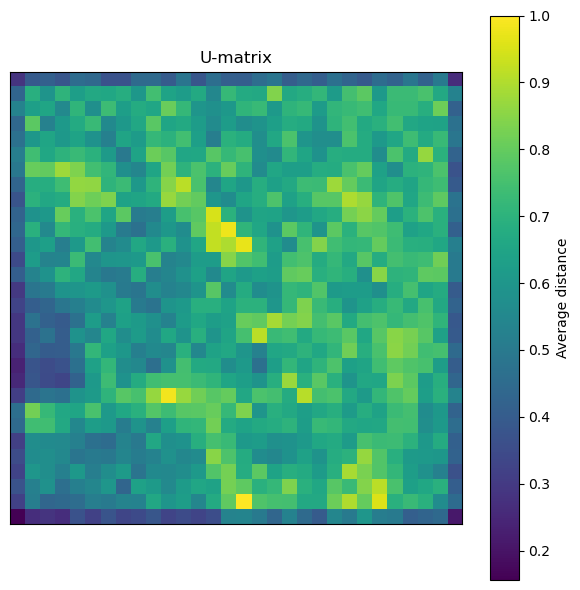

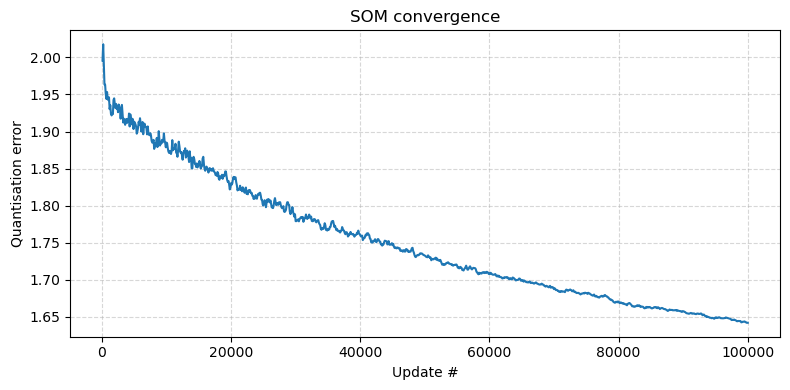

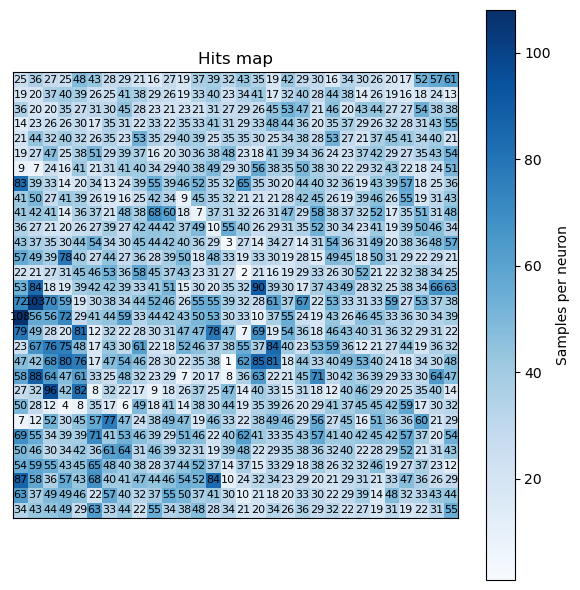

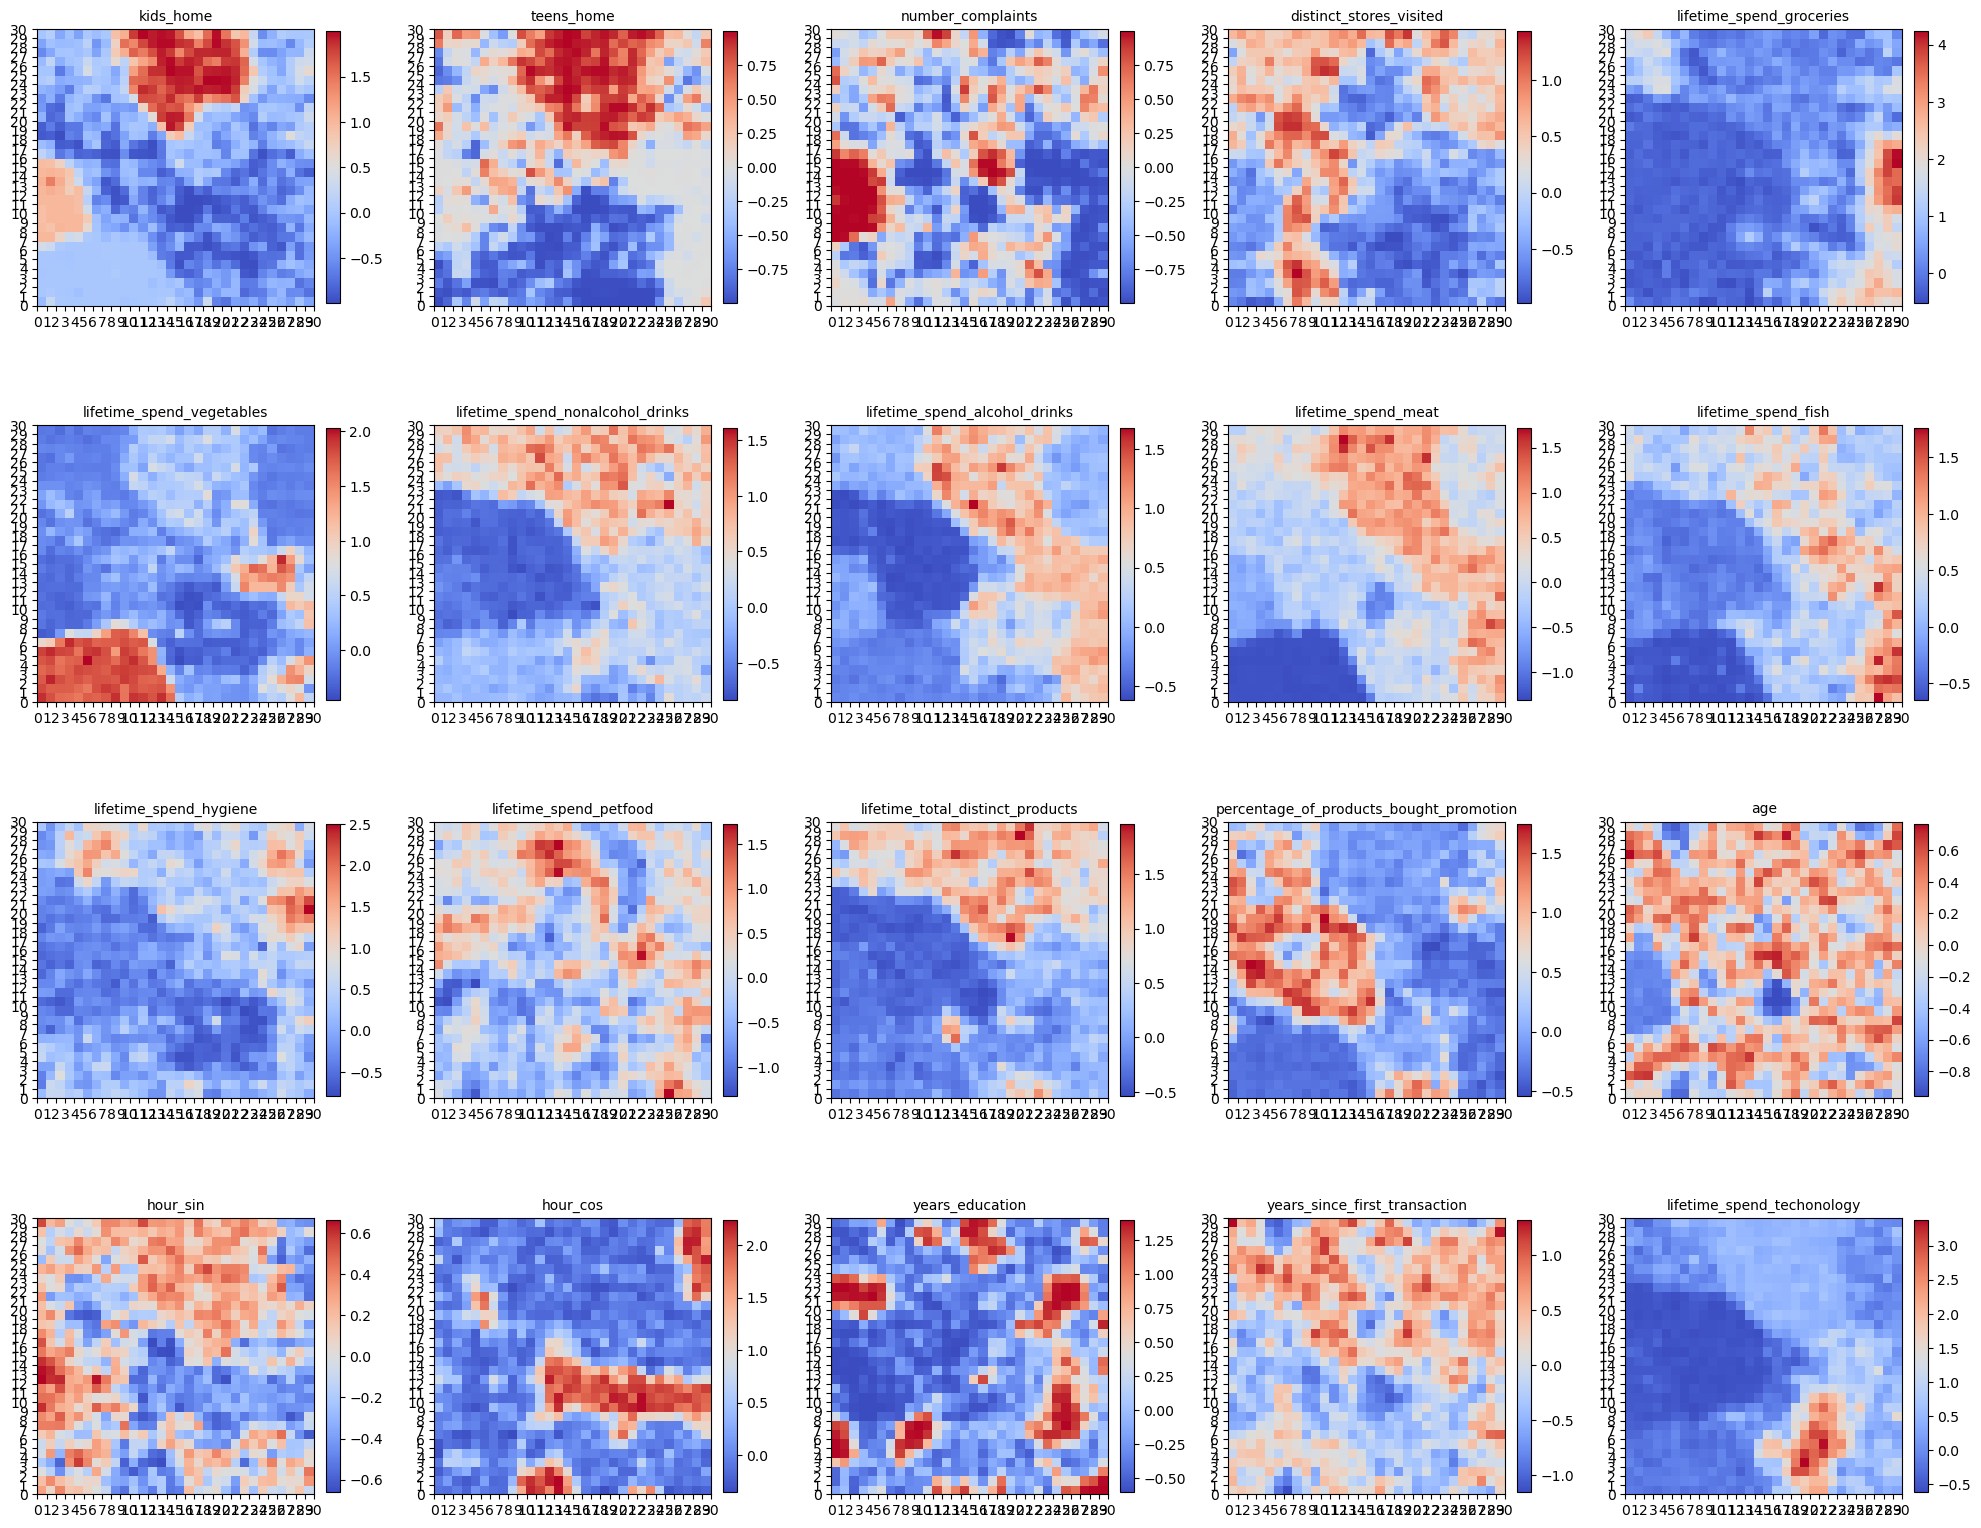

In [8]:
data_df   = info_clustering.copy()
data_arr  = data_df.to_numpy(dtype=float)
INPUT_LEN = data_arr.shape[1]


np.random.seed(42)          

GRID_SIZE = 30
som = MiniSom(
    x                = GRID_SIZE,
    y                = GRID_SIZE,
    input_len        = INPUT_LEN,
    sigma            = 1.5,          
    learning_rate    = 1,          
    neighborhood_function = 'gaussian',
    random_seed      = 42            
)

som.random_weights_init(data_arr)
grid_x, grid_y = som.get_weights().shape[:2]

N_UPDATES      = 100000     
SAMPLE_EVERY   = 100
quant_errors = train_som_with_qe(som, data_arr, N_UPDATES, SAMPLE_EVERY)
plot_u_matrix(som)
plot_quant_errors(quant_errors, SAMPLE_EVERY)
bmu_coords = np.array([som.winner(v) for v in data_arr])        
flat_ids   = np.ravel_multi_index(bmu_coords.T, dims=(grid_x, grid_y))
data_df['cluster'] = flat_ids
plot_hits_map(som, data_arr)
plot_feature_maps(som, list(info_clustering.columns),grid_size=GRID_SIZE, n_cols=5)

